In [6]:
from MHLA.mhla_image_classification.models.mhla_vit import MHLA_ViT
import torchvision.models as models

import torch
import os
from torch.utils.data import Dataset, DataLoader
import numpy as np
import torch.nn as nn
from torchvision import transforms
import matplotlib.pyplot as plt
from PIL import Image

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
class BreastDataset(Dataset):
    def __init__(self, root_dir, transform=None, split='train', test_size=0.2):
        self.data = []
        self.labels = []
        self.classes = ['benign', 'malignant', 'normal']
        self.class_to_idx = {'benign': 0, 'malignant': 1, 'normal': 2}

        for class_name in self.classes:
            class_path = os.path.join(root_dir, class_name)
            if os.path.exists(class_path):
                files = os.listdir(class_path)
                image_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))
                             and 'mask' not in f.lower()]

                for img_name in image_files:
                    img_path = os.path.join(class_path, img_name)
                    self.data.append(img_path)
                    self.labels.append(self.class_to_idx[class_name])

                print(f"Class '{class_name}': {len(image_files)} images")


        print(f"Total images collected: {len(self.data)}")

        indices = np.arange(len(self.data))

        val_idx, train_idx = indices[:int(len(indices) * test_size)], indices[int(len(indices) * test_size):]

        if split == 'train':
            self.data = [self.data[i] for i in train_idx]
            self.labels = [self.labels[i] for i in train_idx]
        else:
            self.data = [self.data[i] for i in val_idx]
            self.labels = [self.labels[i] for i in val_idx]

        print(f"{split} set size: {len(self.data)}")

        self.transform = transform or transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.data[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

In [9]:
def train_epoch(model, train_loader, criterion, optimizer, device, epoch):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        if batch_idx % 5 == 0:
            print(f'Epoch: {epoch} | Batch: {batch_idx}/{len(train_loader)} | '
                  f'Loss: {loss.item():.4f} | Acc: {100.*correct/total:.2f}%')

    return total_loss/len(train_loader), 100.*correct/total

def validate(model, val_loader, criterion, device):
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return val_loss/len(val_loader), 100.*correct/total


In [10]:
def run_experiment(model_type='mhla', data_dir=None, epochs=10, batch_size=8):
    data_dir = '/content/drive/MyDrive/breast_dataset/Dataset_BUSI_with_GT'

    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # possible_paths = [
    #     'breast_dataset/Dataset_BUSI_with_GT',
    #     'Dataset_BUSI_with_GT',
    #     '../Dataset_BUSI_with_GT',
    #     './Dataset_BUSI_with_GT',
    #     '/content/Dataset_BUSI_with_GT'
    # ]

    # for path in possible_paths:
    #     if os.path.exists(path):
    #         data_dir = path
    #         print(f"Found dataset at: {data_dir}")
    #         break

    print("\nCreating datasets...")


    # Создаем модель
    if model_type == 'mhla':
        train_transform = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.1, contrast=0.1),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                              std=[0.229, 0.224, 0.225])
        ])

        val_transform = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                              std=[0.229, 0.224, 0.225])
        ])

        train_dataset = BreastDataset(data_dir, transform=train_transform, split='train')
        val_dataset = BreastDataset(data_dir, transform=val_transform, split='val')

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)


        print("\nInitializing MHLA model...")
        model = model = MHLA_ViT(
            img_size=256,
            patch_size=16,
            num_classes=3,
            piece_size=4,
            class_token=False,
            global_pool='avg',
            padding=False
        ).to(device)
    else:
        train_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.1, contrast=0.1),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                              std=[0.229, 0.224, 0.225])
        ])

        val_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                              std=[0.229, 0.224, 0.225])
        ])

        train_dataset = BreastDataset(data_dir, transform=train_transform, split='train')
        val_dataset = BreastDataset(data_dir, transform=val_transform, split='val')

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

        print("\nInitializing ViT model...")
        model = models.vit_b_16(weights='DEFAULT').to(device)
        num_features = model.heads.head.in_features
        model.heads.head = nn.Linear(num_features, 3).to(device)

    # Подсчет параметров
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_params:,}")

    # Оптимизатор и функция потерь
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    # Обучение
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    print(f"\nStarting training for {epochs} epochs...")
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, epoch)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"\nEpoch {epoch}/{epochs} Summary:")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        print("-" * 50)

    return {
        'model_type': model_type,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs,
        'final_train_acc': train_accs[-1],
        'final_val_acc': val_accs[-1],
        'best_val_acc': max(val_accs)
    }

BREAST CANCER CLASSIFICATION WITH MHLA
Using device: cuda:0

Creating datasets...
Class 'benign': 437 images
Class 'malignant': 210 images
Class 'normal': 133 images
Total images collected: 780
train set size: 624
Class 'benign': 437 images
Class 'malignant': 210 images
Class 'normal': 133 images
Total images collected: 780
val set size: 156

Initializing MHLA model...
Total parameters: 85,845,507

Starting training for 15 epochs...
Epoch: 1 | Batch: 0/20 | Loss: 1.1024 | Acc: 43.75%
Epoch: 1 | Batch: 5/20 | Loss: 1.2867 | Acc: 39.58%
Epoch: 1 | Batch: 10/20 | Loss: 1.0201 | Acc: 44.03%
Epoch: 1 | Batch: 15/20 | Loss: 1.1751 | Acc: 42.58%

Epoch 1/15 Summary:
Train Loss: 1.4177, Train Acc: 42.95%
Val Loss: 0.7624, Val Acc: 100.00%
--------------------------------------------------
Epoch: 2 | Batch: 0/20 | Loss: 1.0454 | Acc: 46.88%
Epoch: 2 | Batch: 5/20 | Loss: 1.1207 | Acc: 45.83%
Epoch: 2 | Batch: 10/20 | Loss: 1.1238 | Acc: 45.45%
Epoch: 2 | Batch: 15/20 | Loss: 1.1132 | Acc: 46.48

100%|██████████| 330M/330M [00:01<00:00, 189MB/s]


Total parameters: 85,800,963

Starting training for 15 epochs...
Epoch: 1 | Batch: 0/20 | Loss: 1.1487 | Acc: 34.38%
Epoch: 1 | Batch: 5/20 | Loss: 1.0470 | Acc: 37.50%
Epoch: 1 | Batch: 10/20 | Loss: 1.0340 | Acc: 41.19%
Epoch: 1 | Batch: 15/20 | Loss: 0.9749 | Acc: 40.62%

Epoch 1/15 Summary:
Train Loss: 1.0623, Train Acc: 43.91%
Val Loss: 0.4481, Val Acc: 78.85%
--------------------------------------------------
Epoch: 2 | Batch: 0/20 | Loss: 0.8916 | Acc: 65.62%
Epoch: 2 | Batch: 5/20 | Loss: 0.6227 | Acc: 66.15%
Epoch: 2 | Batch: 10/20 | Loss: 0.6026 | Acc: 67.33%
Epoch: 2 | Batch: 15/20 | Loss: 0.6407 | Acc: 68.75%

Epoch 2/15 Summary:
Train Loss: 0.6815, Train Acc: 70.51%
Val Loss: 0.3148, Val Acc: 88.46%
--------------------------------------------------
Epoch: 3 | Batch: 0/20 | Loss: 0.4603 | Acc: 87.50%
Epoch: 3 | Batch: 5/20 | Loss: 0.3933 | Acc: 80.21%
Epoch: 3 | Batch: 10/20 | Loss: 0.6825 | Acc: 78.41%
Epoch: 3 | Batch: 15/20 | Loss: 0.4662 | Acc: 77.73%

Epoch 3/15 Summa

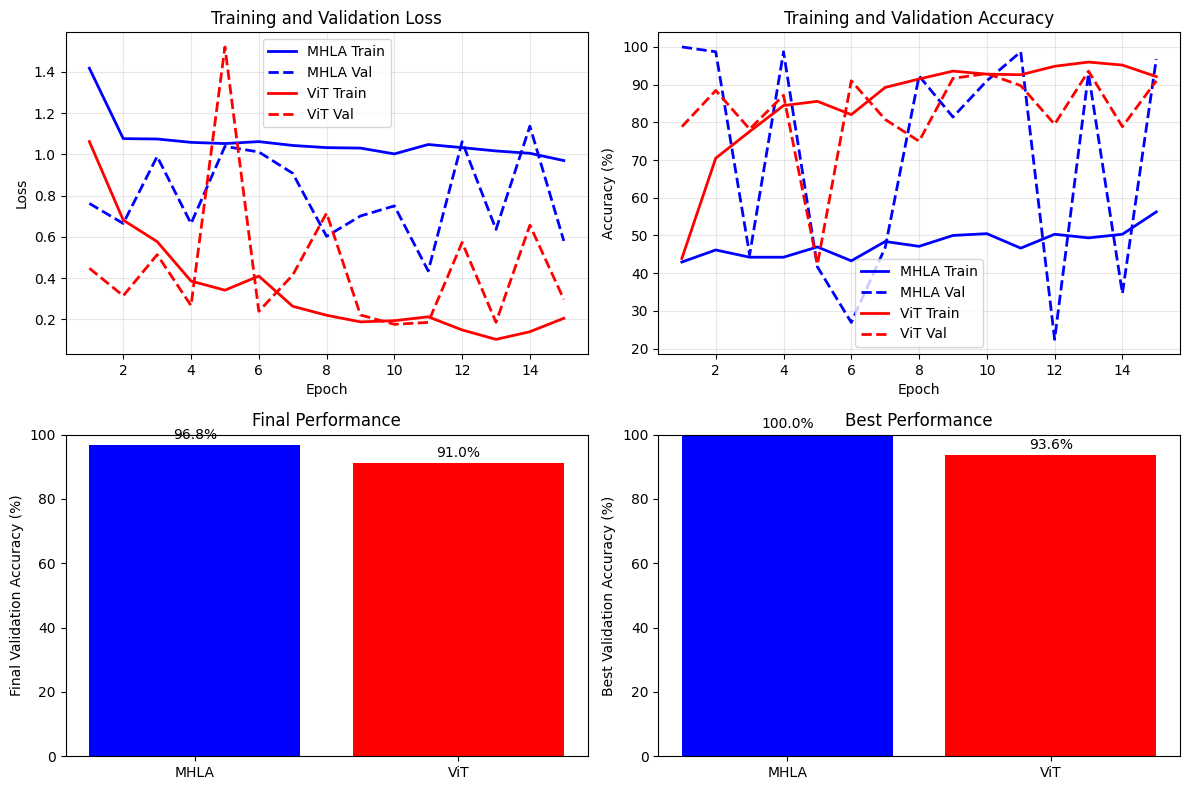


FINAL COMPARISON
MHLA - Best Val Accuracy: 100.00%
ViT - Best Val Accuracy: 93.59%
Improvement: 6.41%


In [11]:
def plot_results(mhla_results, vit_results):
    """Визуализация результатов"""
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    epochs = range(1, len(mhla_results['train_losses']) + 1)

    # Loss кривые
    axes[0, 0].plot(epochs, mhla_results['train_losses'], label='MHLA Train', color='blue', linewidth=2)
    axes[0, 0].plot(epochs, mhla_results['val_losses'], label='MHLA Val', color='blue', linestyle='--', linewidth=2)
    axes[0, 0].plot(epochs, vit_results['train_losses'], label='ViT Train', color='red', linewidth=2)
    axes[0, 0].plot(epochs, vit_results['val_losses'], label='ViT Val', color='red', linestyle='--', linewidth=2)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training and Validation Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Accuracy кривые
    axes[0, 1].plot(epochs, mhla_results['train_accs'], label='MHLA Train', color='blue', linewidth=2)
    axes[0, 1].plot(epochs, mhla_results['val_accs'], label='MHLA Val', color='blue', linestyle='--', linewidth=2)
    axes[0, 1].plot(epochs, vit_results['train_accs'], label='ViT Train', color='red', linewidth=2)
    axes[0, 1].plot(epochs, vit_results['val_accs'], label='ViT Val', color='red', linestyle='--', linewidth=2)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].set_title('Training and Validation Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Final accuracy comparison
    models = ['MHLA', 'ViT']
    final_accs = [mhla_results['final_val_acc'], vit_results['final_val_acc']]

    bars = axes[1, 0].bar(models, final_accs, color=['blue', 'red'])
    axes[1, 0].set_ylabel('Final Validation Accuracy (%)')
    axes[1, 0].set_title('Final Performance')
    axes[1, 0].set_ylim([0, 100])

    for bar, acc in zip(bars, final_accs):
        height = bar.get_height()
        axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 1,
                       f'{acc:.1f}%', ha='center', va='bottom')

    # Best accuracy comparison
    best_accs = [mhla_results['best_val_acc'], vit_results['best_val_acc']]

    bars = axes[1, 1].bar(models, best_accs, color=['blue', 'red'])
    axes[1, 1].set_ylabel('Best Validation Accuracy (%)')
    axes[1, 1].set_title('Best Performance')
    axes[1, 1].set_ylim([0, 100])

    for bar, acc in zip(bars, best_accs):
        height = bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 1,
                       f'{acc:.1f}%', ha='center', va='bottom')

    plt.tight_layout()
    plt.savefig('comparison_results.png', dpi=150, bbox_inches='tight')
    plt.show()


if __name__ == "__main__":
    print("=" * 60)
    print("BREAST CANCER CLASSIFICATION WITH MHLA")
    print("=" * 60)

    mhla_full = run_experiment(model_type='mhla', epochs=15, batch_size=32)
    print("\n" + "=" * 60)
    print("FULL TRAINING - ViT (15 epochs)")
    print("=" * 60)
    vit_full = run_experiment(model_type='vit', epochs=15, batch_size=32)

    # Визуализация
    print("\n" + "=" * 60)
    print("GENERATING COMPARISON PLOTS")
    print("=" * 60)
    plot_results(mhla_full, vit_full)

    # Вывод результатов
    print("\n" + "=" * 60)
    print("FINAL COMPARISON")
    print("=" * 60)
    print(f"MHLA - Best Val Accuracy: {mhla_full['best_val_acc']:.2f}%")
    print(f"ViT - Best Val Accuracy: {vit_full['best_val_acc']:.2f}%")
    print(f"Improvement: {(mhla_full['best_val_acc'] - vit_full['best_val_acc']):.2f}%")